# End-to-End FM/RDS Receiver

This notebook implements an **end-to-end digital RDS receiver** starting from an SDR recording of a broadcast-FM signal.

> **Input:** `mpx.wav`, containing interleaved I/Q samples from an SDR recording.  
> **Output:** decoded RDS information such as Programme Type (PTY), programme identification information, and RadioText when present.

**Project Roadmap**

| Stage | Receiver operation | DSP concept | Diagnostic |
|---|---|---|---|
| 1 | FM demodulation | Instantaneous phase | MPX spectrum |
| 2 | RDS downconversion | Complex mixing / DDC | Shifted spectrum |
| 3 | Channel filtering + resampling | FIR + polyphase resampling | Filter response + PSD |
| 4 | Carrier recovery | Costas PLL | Constellation + frequency tracking |
| 5 | Matched filtering | RRC matched filter | Filter response |
| 6 | Chip timing recovery | Mueller & Müller TED | Synchronized constellation |
| 7 | Binary decoding | BPSK + Manchester + differential decoding | Chip/bit decisions |
| 8 | RDS synchronization | Syndrome + CRC | Valid/invalid blocks |
| 9 | RDS parsing | Protocol field extraction | PI / PTY / RadioText |

## 1. FM Demodulation and MPX Spectrum

Before extracting RDS, we need the **FM multiplex (MPX)** signal.

For a broadcast-FM signal, the demodulated MPX contains several components:

| Frequency | Component | Purpose |
|---:|---|---|
| 0–15 kHz | $L+R$ | Mono/stereo audio |
| 19 kHz | Stereo pilot | Reference for stereo decoding |
| 23–53 kHz | $L-R$ DSB-SC | Stereo difference signal |
| 57 kHz | RDS subcarrier | Digital RDS data |

The RDS signal is therefore not an independent audio stream: it is a **57 kHz subcarrier embedded in the FM MPX**.

The first code cell loads the SDR recording and performs FM quadrature demodulation.

### 1.1 Load the SDR recording and FM-demodulate it

The WAV file contains interleaved I/Q samples. We reconstruct the complex analytic signal

$$
z[n] = I[n] + jQ[n].
$$

FM quadrature demodulation then estimates the instantaneous phase difference:

$$
x[n] = \frac{1}{2}\arg\left(z[n]z^*[n+1]\right).
$$

The resulting real-valued signal is the **FM MPX baseband**.

The cell also plays the demodulated MPX so that the signal can be inspected acoustically, although the important information for this project is the spectrum.

In [ ]:
import numpy as np
from scipy.signal import resample_poly, firwin, freqz, bilinear, lfilter
from scipy.io import wavfile
import matplotlib.pyplot as plt
import math
import sounddevice as sd

# For testing purposes, use the example wav files provided in the wav_examples folder.
filename = './wav_examples/example.wav'
fs, x_iq = wavfile.read(filename)

# Combine I and Q
# Separate interleaved I and Q samples
i_data = x_iq[0::2]
q_data = x_iq[1::2]

x = i_data + 1j * q_data

# FM demodulate to get MPX
x = 0.5 * np.angle(x[0:-1] * np.conj(x[1:]))

# Play it
sd.play(x, fs)

print(f"[+] Sample Rate: {fs} Hz")

sample_rate = fs

[+] Sample Rate: 192000 Hz


### 1.2 Inspect the FM MPX spectrum

The PSD should reveal the characteristic broadcast-FM multiplex structure.

The most important feature for this project is the **57 kHz RDS subcarrier**. We will isolate this component in the next stages rather than attempting to decode the audio channels.

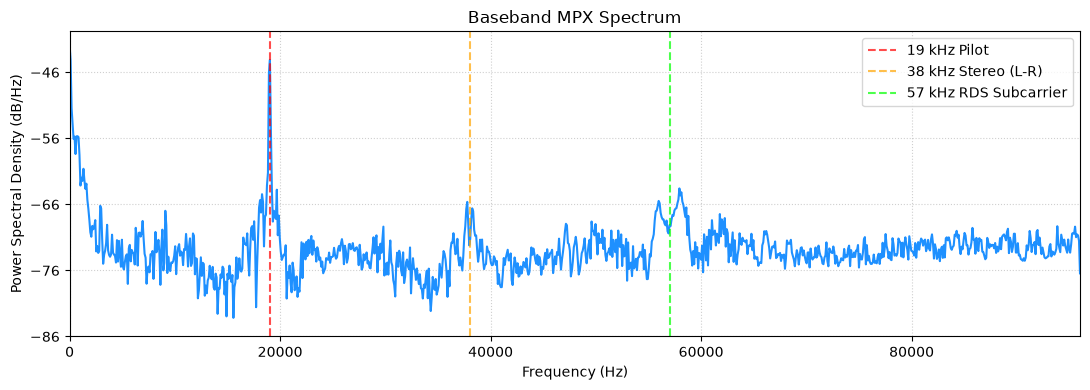

In [2]:
# -- PLOTS
plt.figure(figsize=(11, 4))
plt.psd(x[: int(fs * 2)], NFFT=2048, Fs=fs, color="dodgerblue")
plt.axvline(19e3, color="red", linestyle="--", alpha=0.7, label="19 kHz Pilot")
plt.axvline(38e3, color="orange", linestyle="--", alpha=0.7, label="38 kHz Stereo (L-R)")
plt.axvline(57e3, color="lime", linestyle="--", alpha=0.7, label="57 kHz RDS Subcarrier")
plt.title("Baseband MPX Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB/Hz)")
plt.xlim(0, fs / 2)
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 2. RDS Subcarrier Downconversion

RDS is transmitted on a **57 kHz suppressed-carrier subcarrier**. To process it as a digital baseband signal, we translate that subcarrier to DC.

For a complex mixer,

$$ x_{\mathrm{bb}}[n]=
x[n]e^{-j2\pi f_0 n/f_s},
\qquad f_0=57\text{ kHz}.
$$

This shifts the positive-frequency RDS component from 57 kHz to 0 Hz.

After mixing, the desired RDS signal becomes a complex low-frequency signal that can be isolated with a low-pass filter. This is the standard **digital downconversion (DDC)** pattern used in software-defined receivers.

In [3]:
# Frequency shift
N = len(x)
f_o = -57e3                         # amount we need to shift by
t = np.arange(N)/sample_rate        # time vector
x = x * np.exp(2j * np.pi * f_o*t)  # down shift

## 3. RDS Channel Filtering and Resampling

After downconversion, the RDS signal is centered at DC. The original 192 kHz sampling rate used for the complete MPX FM signal is now unnecessarily high.

We therefore:

1. Apply a low-pass FIR filter to isolate the RDS channel.
2. Resample to **19 kHz**.

The RDS information bit rate is

$$
R_b = 1187.5\text{ bit/s}.
$$

However, RDS uses **biphase/Manchester coding**, so each information bit becomes two chips. Therefore the chip rate is

$$
R_c = 2R_b = 2375\text{ chips/s}.
$$

At 19 kHz this gives

$$
\frac{19000}{2375}=8
$$

samples per chip, or **16 samples per information bit**.

This distinction is important: the timing-recovery stage operates on the **2375 chip/s waveform**, not directly on the 1187.5 bit/s data stream.

### 3.1 Low-pass filtering and resampling

The 151-tap FIR filter uses a 3 kHz cutoff. This comfortably contains the RDS baseband while suppressing components outside the desired channel.

After filtering, the signal is resampled from the original sample rate to 19 kHz. Because the new rate is synchronized with the 19 kHz pilot reference and the RDS chip rate, it is convenient for subsequent timing recovery.

The three plots provide useful diagnostics:

- **Filter response:** what frequencies the FIR passes/rejects.
- **Before vs. after filtering:** whether the RDS channel has been isolated.
- **Final 19 kHz spectrum:** the signal that enters the digital receiver chain.

[+] Resampled to: 19000.0 Hz (Factor: 19.0/192)


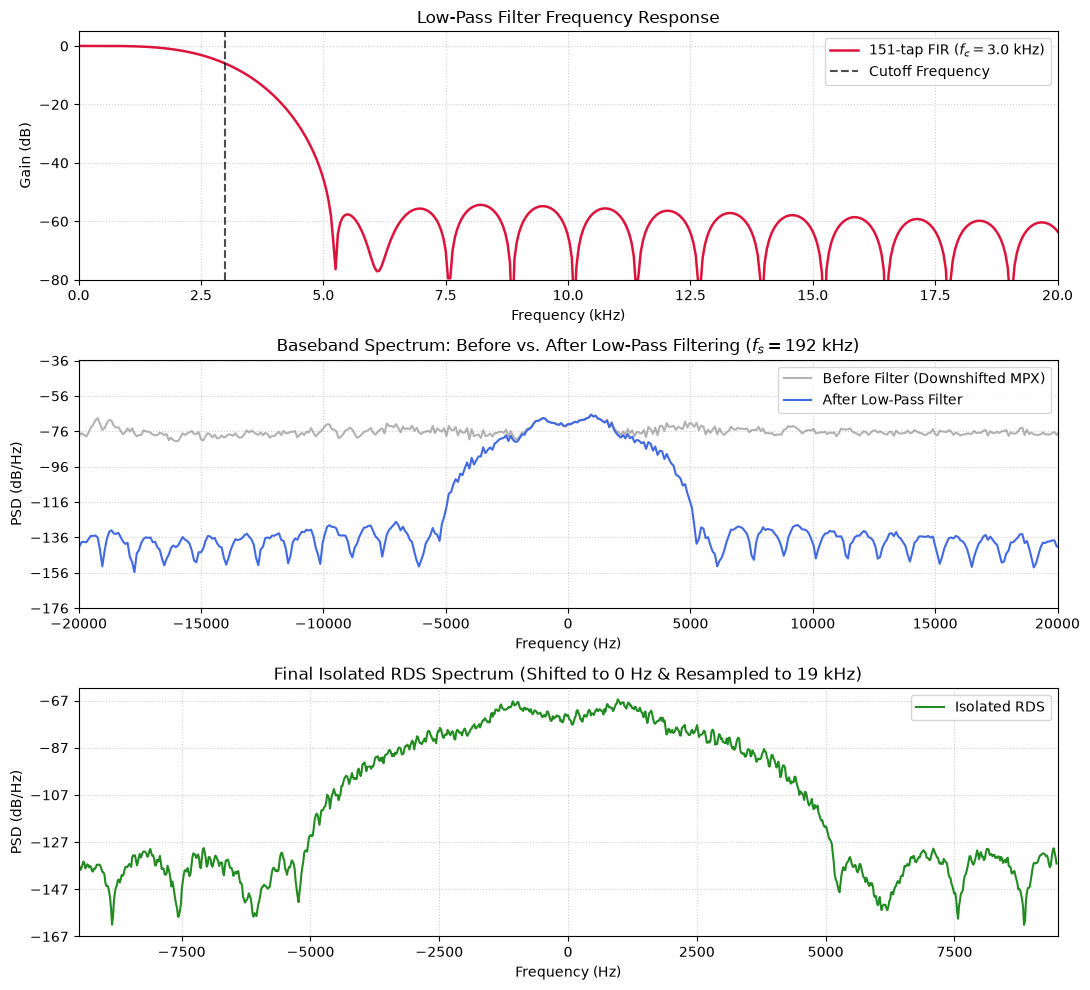

In [4]:
# Save the unfiltered downshifted signal for comparison
x_shifted = x.copy()

# FIR Low-Pass Filter
numtaps = 151 
cutoff = 3.0e3
taps = firwin(numtaps=numtaps, cutoff=cutoff, fs=sample_rate)
w, h = freqz(taps, worN=2048, fs=sample_rate) # Frequency response of the filter
 
# Apply Low-Pass Filter
x_filtered = np.convolve(x, taps, 'valid')

# Note: In the tutorial (fs = 250 kHz), the signal gets decimated to 25 kHz
#       and then resampled to 19 kHz, for computational efficiancy.
#       In our case, fs = 192 kHz, so we directly resample to 19 kHz without decimation. 

# Resample to 19 kHz
target_fs = 19e3
gcd = math.gcd(int(fs), int(target_fs))
up_factor = target_fs // gcd
down_factor = sample_rate // gcd
x_resampled = resample_poly(x_filtered, up_factor, down_factor)

# Update signal reference
x = x_resampled
sample_rate = target_fs
print(f"[+] Resampled to: {sample_rate} Hz (Factor: {up_factor}/{down_factor})")

# -- PLOTS
fig, axs = plt.subplots(3, 1, figsize=(11, 10))

# --- PLOT: FIR Filter Frequency Response ---
axs[0].plot(w / 1e3, 20 * np.log10(np.abs(h)), color='crimson', lw=1.8, label=f'{numtaps}-tap FIR ($f_c = {cutoff/1e3:.1f}$ kHz)')
axs[0].axvline(cutoff / 1e3, color='black', linestyle='--', alpha=0.7, label='Cutoff Frequency')
axs[0].set_title("Low-Pass Filter Frequency Response")
axs[0].set_xlabel("Frequency (kHz)")
axs[0].set_ylabel("Gain (dB)")
axs[0].set_xlim(0, 20)  # Focus on 0 - 20 kHz
axs[0].set_ylim(-80, 5)
axs[0].grid(True, linestyle=":", alpha=0.6)
axs[0].legend(loc="upper right")

# --- PLOT: Spectrum Before vs. After Filtering (at 192 kHz) ---
N_fft = 2048
# Before filter
axs[1].psd(x_shifted[: int(192e3 * 2)], NFFT=N_fft, Fs=192e3, color="gray", alpha=0.6, label="Before Filter (Downshifted MPX)")
# After filter
axs[1].psd(x_filtered[: int(192e3 * 2)], NFFT=N_fft, Fs=192e3, color="royalblue", lw=1.5, label="After Low-Pass Filter")
axs[1].set_title("Baseband Spectrum: Before vs. After Low-Pass Filtering ($f_s = 192$ kHz)")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("PSD (dB/Hz)")
axs[1].set_xlim(-20e3, 20e3)  # Zoomed into ±20 kHz around DC
axs[1].grid(True, linestyle=":", alpha=0.6)
axs[1].legend(loc="upper right")

# --- PLOT: Final Isolated RDS Spectrum (at 19 kHz) ---
axs[2].psd(x[: int(sample_rate * 2)], NFFT=1024, Fs=sample_rate, color="forestgreen", lw=1.5, label="Isolated RDS")
axs[2].set_title("Final Isolated RDS Spectrum (Shifted to 0 Hz & Resampled to 19 kHz)")
axs[2].set_xlabel("Frequency (Hz)")
axs[2].set_ylabel("PSD (dB/Hz)")
axs[2].set_xlim(-sample_rate / 2,   sample_rate / 2)
axs[2].grid(True, linestyle=":", alpha=0.6)
axs[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. Carrier Phase and Frequency Synchronization — Costas Loop

The downconverted RDS signal is BPSK-like, but the receiver does not know the exact residual carrier phase or frequency.

A **second-order Costas loop** tracks these errors and rotates the constellation back onto the real axis.

Conceptually:

1. Derotate the incoming sample using the current phase estimate.
2. Measure a decision-directed BPSK phase error.
3. Update the estimated frequency and phase.
4. Repeat for every sample.

A locked constellation should have most of its energy along the **I axis**, with little systematic rotation over time.

Carrier recovery is performed before timing recovery so that the timing detector sees a stable constellation.

In [5]:
# Power normalize the filtered signal before feeding into the PLL
samples = x / (np.sqrt(np.mean(np.abs(x)**2)) + 1e-12)

N = len(samples)
x_carrier_locked = np.zeros(N, dtype=np.complex64)
freq_log = np.zeros(N)

phase = 0.0
freq = 0.0

# Loop bandwidth parameters tuned for the oversampled 19 kHz rate
alpha = 0.02   # Proportional gain: tracks rapid phase shifts
beta = 0.0001  # Integral gain: tracks steady-state carrier frequency error

for i in range(N):
    # 1. Derotate input sample by current phase estimate
    x_carrier_locked[i] = samples[i] * np.exp(-1j * phase)

    # 2. Decision-directed BPSK phase error detector
    error = np.sign(np.real(x_carrier_locked[i])) * np.imag(x_carrier_locked[i])

    # 3. Loop Filter: Update frequency and phase
    freq += beta * error
    phase += freq + (alpha * error)

    # 4. Keep phase bounded
    phase = phase % (2.0 * np.pi)

    # 5. Log frequency offset in Hz
    freq_log[i] = (freq * sample_rate) / (2.0 * np.pi)

print(f"[+] Costas Lock complete. Estimated Mean Offset: {np.mean(freq_log[-5000:]):.2f} Hz")


[+] Costas Lock complete. Estimated Mean Offset: 0.01 Hz


## 5. Matched Filtering

After carrier recovery, the signal is passed through a **root-raised-cosine (RRC) filter**.

A matched filter improves the signal-to-noise ratio at the sampling instants and shapes the received waveform so that the symbol/chip timing detector has a clearer eye opening.

Here the RDS chip rate is

$$
R_c = 2375\text{ chips/s},
$$

so at 19 kHz the input contains 8 samples/chip.

The RRC roll-off and filter length are design choices for this implementation; they are not additional fields in the RDS standard.

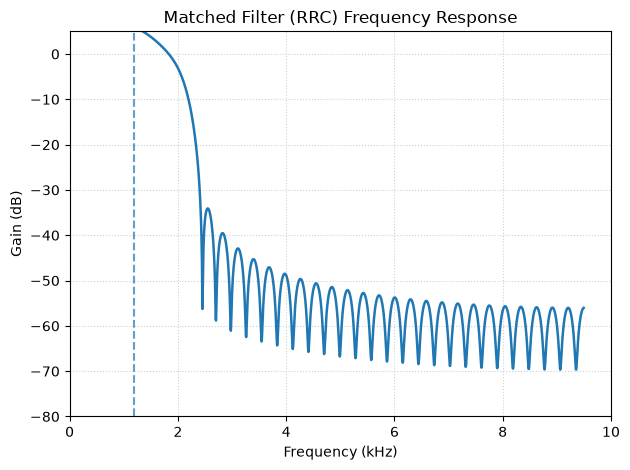

In [6]:
def rrcosfilter(N, alpha, Ts, Fs):
    """
    Root-Raised-Cosine (RRC) filter.
    N: Number of taps
    alpha: Roll-off factor (1.0 for RDS)
    Ts: Symbol period (1 / chip_rate)
    Fs: Sample rate
    """
    t = (np.arange(N) - N / 2) / Fs
    h = np.zeros(N, dtype=float)
    for i in range(N):
        if t[i] == 0.0:
            h[i] = 1.0 - alpha + (4 * alpha / np.pi)
        elif alpha != 0 and np.isclose(np.abs(t[i]), Ts / (4 * alpha)):
            h[i] = (alpha / np.sqrt(2)) * (((1 + 2 / np.pi) * (np.sin(np.pi / (4 * alpha)))) + ((1 - 2 / np.pi) * (np.cos(np.pi / (4 * alpha)))))
        else:
            h[i] = (np.sin(np.pi * t[i] * (1 - alpha) / Ts) + 4 * alpha * (t[i] / Ts) * np.cos(np.pi * t[i] * (1 + alpha) / Ts)) / (np.pi * t[i] * (1 - (4 * alpha * t[i] / Ts)**2) / Ts)
    return h / np.sqrt(np.sum(h**2)) # Normalize energy

chip_rate = 2375.0      # RDS Manchester chip rate
sps = 8                 # Samples per chip (19000 Hz / 2375 Hz)
num_taps = 65
rrc_taps = rrcosfilter(num_taps, alpha=1.0, Ts=1/chip_rate, Fs=sample_rate)

x_matched = lfilter(rrc_taps, 1.0, x_carrier_locked)
w_m, h_m = freqz(rrc_taps, worN=2048, fs=sample_rate) # Frequency response of the filter


# --- PLOT: Matched Filter Frequency Response ---
plt.plot(w_m / 1e3, 20 * np.log10(np.maximum(np.abs(h_m), 1e-12)), lw=1.8, label='RRC matched filter')
plt.axvline(chip_rate / 2 / 1e3, linestyle='--', alpha=0.7, label='Chip Nyquist frequency')
plt.title("Matched Filter (RRC) Frequency Response")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Gain (dB)")
plt.xlim(0, 10) 
plt.ylim(-80, 5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 6. Chip Timing Recovery - Mueller & Müller

We now need to determine **where to sample each RDS chip**.

Even with the correct sample rate, the first useful sampling instant is generally not known exactly. The Mueller & Müller (M&M) timing recovery loop estimates the fractional timing error and moves the sampling point toward the centre of the eye.

### Processing

- Interpolate the signal to obtain a fine timing grid.
- Make tentative symbol/chip decisions.
- Compute the M&M timing error.
- Update the fractional sampling position.
- Produce approximately **one sample per RDS chip**.

After this stage, the signal is reduced from 8 samples/chip to 1 sample/chip, making binary decoding much simpler.

In [7]:
# Interpolate by 32 for fine sub-sample timing resolution
interp_factor = 32
samples_interpolated = resample_poly(x_matched, interp_factor, 1)

sps = 8
mu = 0.01          # Fractional sample phase
gain_mm = 0.005    # M&M loop gain

max_symbols = len(x_matched) // sps + 100
out = np.zeros(max_symbols, dtype=np.complex64)
out_rail = np.zeros(max_symbols, dtype=np.complex64)

i_in = 0           
i_out = 2          

while (i_in + sps) < len(x_matched) and i_out < max_symbols:
    interp_idx = int(i_in * interp_factor + np.round(mu * interp_factor))
    if interp_idx >= len(samples_interpolated):
        break

    out[i_out] = samples_interpolated[interp_idx]

    # Hard-decision slicing for BPSK: {-1.0, +1.0}
    dec_i = 1.0 if np.real(out[i_out]) > 0 else -1.0
    dec_q = 1.0 if np.imag(out[i_out]) > 0 else -1.0
    out_rail[i_out] = dec_i + 1j * dec_q

    # Mueller & Müller Timing Error Detector
    x_diff = (out_rail[i_out] - out_rail[i_out - 2]) * np.conj(out[i_out - 1])
    y_diff = (out[i_out] - out[i_out - 2]) * np.conj(out_rail[i_out - 1])
    mm_val = np.clip(np.real(y_diff - x_diff), -2.0, 2.0)

    # Update fractional delay and base index
    mu += sps + gain_mm * mm_val
    i_in += int(np.floor(mu))
    mu = mu - np.floor(mu)

    i_out += 1

# Extract valid symbols
symbols = out[2:i_out]
print(f"[+] Extracted symbols: {len(symbols)}")

[+] Extracted symbols: 94998


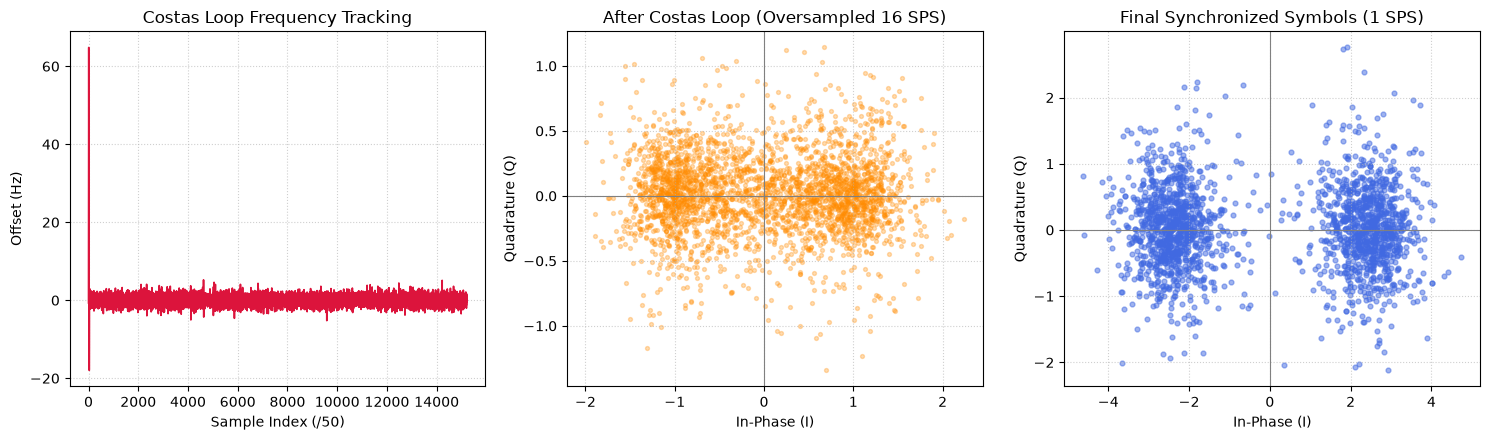

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

# Plot 1: Costas Loop Frequency Tracking
axs[0].plot(freq_log[::50], color="crimson", lw=1.2)
axs[0].set_title("Costas Loop Frequency Tracking")
axs[0].set_xlabel("Sample Index (/50)")
axs[0].set_ylabel("Offset (Hz)")
axs[0].grid(True, linestyle=":", alpha=0.6)

# Plot 2: Oversampled Carrier-Locked Constellation
axs[1].scatter(
    np.real(x_carrier_locked[-3000:]), np.imag(x_carrier_locked[-3000:]),
    color="darkorange", alpha=0.3, s=8
)
axs[1].set_title("After Costas Loop (Oversampled 16 SPS)")
axs[1].set_xlabel("In-Phase (I)")
axs[1].set_ylabel("Quadrature (Q)")
axs[1].grid(True, linestyle=":", alpha=0.6)
axs[1].axhline(0, color="grey", lw=0.8)
axs[1].axvline(0, color="grey", lw=0.8)

# Plot 3: Final M&M Synchronized BPSK Symbols
axs[2].scatter(
    np.real(symbols[-2000:]), np.imag(symbols[-2000:]),
    color="royalblue", alpha=0.5, s=12
)
axs[2].set_title("Final Synchronized Symbols (1 SPS)")
axs[2].set_xlabel("In-Phase (I)")
axs[2].set_ylabel("Quadrature (Q)")
axs[2].grid(True, linestyle=":", alpha=0.6)
axs[2].axhline(0, color="grey", lw=0.8)
axs[2].axvline(0, color="grey", lw=0.8)

plt.tight_layout()
plt.show()

### 6.1 Synchronization diagnostics

The three plots compare successive stages of synchronization:

1. **Costas frequency estimate:** shows acquisition and steady-state carrier tracking.
2. **Carrier-locked constellation:** the oversampled signal after carrier recovery.
3. **M&M output:** one sample per chip, where the BPSK decisions should cluster near two levels.

These plots are particularly useful when debugging the receiver. A rotating constellation suggests carrier-recovery problems, while a poorly separated or noisy M&M output can indicate filtering, timing, or SNR problems.

## 7. Biphase/Manchester and Differential Decoding

At this point we have approximately one synchronized sample per **RDS chip**.

The decoding chain is:

**BPSK samples → hard chip decisions → Manchester pair alignment → Manchester decoding → differential decoding**

[+] Manchester alignment offset: 1
    (Violations at offset 0: 19254)
    (Violations at offset 1: 325)
[+] Extracted bits count: 47498
[+] First 50 bits: 
[0 1 0 0 1 1 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1 1 0 0 1 0 0 0 1 0 0 1 1 1 0
 0 0 1 0 0 0 1 1 1 0 0 0 1]


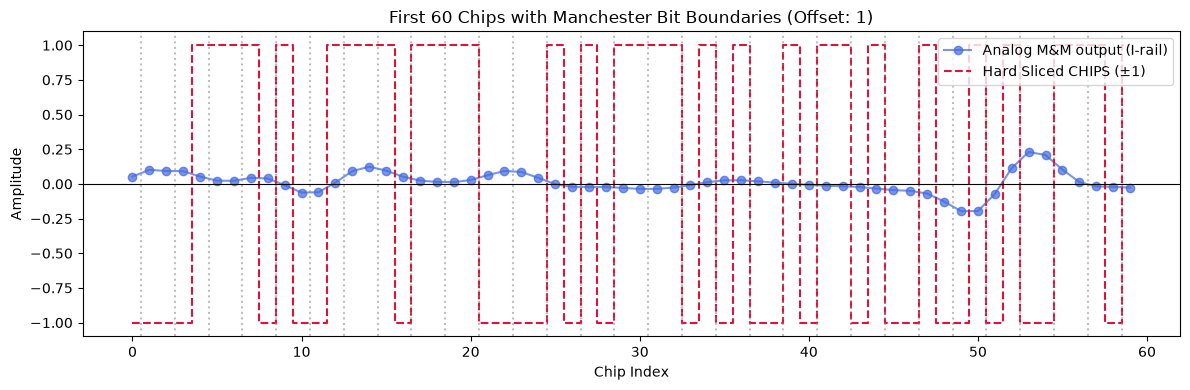

In [9]:
# 1. Hard decision slicing on the complex symbols to get Manchester CHIPS
chips = (np.real(symbols) > 0).astype(int)

# 2. Manchester Alignment (Find correct chip-pair boundaries)
# A valid Manchester pair has alternating chips (1->0 or 0->1).
# We check which offset (0 or 1) has the fewest violations (chip_a == chip_b)
len_0 = len(chips) // 2
errors_offset_0 = np.sum(chips[0::2][:len_0] == chips[1::2][:len_0])

len_1 = len(chips[1:]) // 2
errors_offset_1 = np.sum(chips[1::2][:len_1] == chips[2::2][:len_1])

best_offset = 0 if errors_offset_0 < errors_offset_1 else 1

print(f"[+] Manchester alignment offset: {best_offset}")
print(f"    (Violations at offset 0: {errors_offset_0})")
print(f"    (Violations at offset 1: {errors_offset_1})")

# 3. Decode Manchester chips into raw bits
aligned_chips = chips[best_offset:]

# Since Manchester pairs are [1,0] or [0,1], the data bit can be represented 
# entirely by taking the first chip of the valid pair. (Differential decoding 
# later will automatically fix it if the absolute polarity is inverted).
raw_bits = aligned_chips[0::2]

# 4. Differential decoding: d[k] = b[k] XOR b[k-1]
bits = np.bitwise_xor(raw_bits[1:], raw_bits[:-1])

print(f"[+] Extracted bits count: {len(bits)}")
print(f"[+] First 50 bits: \n{bits[:50]}")


# -- Diagnostic Plots
plt.figure(figsize=(12, 4))
num_chips_to_show = 60

# Plot continuous analog signal
plt.plot(np.real(x[:num_chips_to_show]), "o-", color="royalblue", label="Analog M&M output (I-rail)", alpha=0.7)

# Plot hard-sliced chips
plt.step(
    range(num_chips_to_show),
    chips[:num_chips_to_show] * 2 - 1, # Scale to +/- 1 for visual overlay
    where="mid",
    color="crimson",
    linestyle="--",
    label="Hard Sliced CHIPS (±1)",
)

# Visually mark the valid Manchester bit boundaries based on our best_offset
for boundary in range(best_offset, num_chips_to_show, 2):
    plt.axvline(boundary - 0.5, color="grey", linestyle=":", alpha=0.5)

plt.title(f"First {num_chips_to_show} Chips with Manchester Bit Boundaries (Offset: {best_offset})")
plt.xlabel("Chip Index")
plt.ylabel("Amplitude")
plt.axhline(0, color="black", linewidth=0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 8. RDS Block Synchronization and Error Checking

The recovered bitstream is now passed to the actual **RDS protocol layer**.

RDS transmits information in groups of four 26-bit blocks:

- 16-bit information word
- 10-bit checkword

The checkword is generated using the RDS CRC/syndrome polynomial. The receiver uses the known block offset words **A, B, C/C′ and D** to identify block boundaries and verify them.

### Synchronization 

The decoder:

1. Searches the incoming bitstream for valid RDS syndromes.
2. Confirms a consistent sequence of block offsets.
3. Enters the synchronized state.
4. Checks the CRC of subsequent blocks.
5. Reassembles valid four-block RDS groups.

Only groups passing the relevant consistency/error checks are forwarded to the parser.

The syndrome and offset values below follow the RDS standard (see the Annex references in the implementation comments).

In [10]:
# Constants
syndrome = [383, 14, 303, 663, 748]
offset_pos = [0, 1, 2, 3, 2]
offset_word = [252, 408, 360, 436, 848]

# see Annex B, page 64 of the standard
def calc_syndrome(x, mlen):
    reg = 0
    plen = 10
    for ii in range(mlen, 0, -1):
        reg = (reg << 1) | ((x >> (ii-1)) & 0x01)
        if (reg & (1 << plen)):
            reg = reg ^ 0x5B9
    for ii in range(plen, 0, -1):
        reg = reg << 1
        if (reg & (1 << plen)):
            reg = reg ^ 0x5B9
    return reg & ((1 << plen) - 1) # select the bottom plen bits of reg

# Initialize all the working vars we'll need during the loop
synced = False
presync = False

wrong_blocks_counter = 0
blocks_counter = 0
group_good_blocks_counter = 0

reg = np.uint32(0) # was unsigned long in C++ (64 bits) but numpy doesn't support bitwise ops of uint64, I don't think it gets that high anyway
lastseen_offset_counter = 0
lastseen_offset = 0

# the synchronization process is described in Annex C, page 66 of the standard */
bytes_out = []
for i in range(len(bits)):
    # in C++ reg doesn't get init so it will be random at first, for ours its 0s
    # It was also an unsigned long but never seemed to get anywhere near the max value
    # bits are either 0 or 1
    reg = np.bitwise_or(np.left_shift(reg, 1), bits[i]) # reg contains the last 26 rds bits. these are both bitwise ops
    if not synced:
        reg_syndrome = calc_syndrome(reg, 26)
        for j in range(5):
            if reg_syndrome == syndrome[j]:
                if not presync:
                    lastseen_offset = j
                    lastseen_offset_counter = i
                    presync = True
                else:
                    if offset_pos[lastseen_offset] >= offset_pos[j]:
                        block_distance = offset_pos[j] + 4 - offset_pos[lastseen_offset]
                    else:
                        block_distance = offset_pos[j] - offset_pos[lastseen_offset]
                    if (block_distance*26) != (i - lastseen_offset_counter):
                        presync = False
                    else:
                        print('Sync State Detected')
                        wrong_blocks_counter = 0
                        blocks_counter = 0
                        block_bit_counter = 0
                        block_number = (j + 1) % 4
                        group_assembly_started = False
                        synced = True
            break # syndrome found, no more cycles

    else: # SYNCED
        # wait until 26 bits enter the buffer */
        if block_bit_counter < 25:
            block_bit_counter += 1
        else:
            good_block = False
            dataword = (reg >> 10) & 0xffff
            block_calculated_crc = calc_syndrome(dataword, 16)
            checkword = reg & 0x3ff
            if block_number == 2: # manage special case of C or C' offset word
                block_received_crc = checkword ^ offset_word[block_number]
                if (block_received_crc == block_calculated_crc):
                    good_block = True
                else:
                    block_received_crc = checkword ^ offset_word[4]
                    if (block_received_crc == block_calculated_crc):
                        good_block = True
                    else:
                        wrong_blocks_counter += 1
                        good_block = False
            else:
                block_received_crc = checkword ^ offset_word[block_number] # bitwise xor
                if block_received_crc == block_calculated_crc:
                    good_block = True
                else:
                    wrong_blocks_counter += 1
                    good_block = False

            # Done checking CRC
            if block_number == 0 and good_block:
                group_assembly_started = True
                group_good_blocks_counter = 1
                group = bytearray(8) # 8 bytes filled with 0s
            if group_assembly_started:
                if not good_block:
                    group_assembly_started = False
                else:
                    # raw data bytes, as received from RDS. 8 info bytes, followed by 4 RDS offset chars: ABCD/ABcD/EEEE (in US) which we leave out here
                    # RDS information words
                    # block_number is either 0,1,2,3 so this is how we fill out the 8 bytes
                    group[block_number*2] = (dataword >> 8) & 255
                    group[block_number*2+1] = dataword & 255
                    group_good_blocks_counter += 1
                    #print('group_good_blocks_counter:', group_good_blocks_counter)
                if group_good_blocks_counter == 5:
                    #print(group)
                    bytes_out.append(group) # list of len-8 lists of bytes
            block_bit_counter = 0
            block_number = (block_number + 1) % 4
            blocks_counter += 1
            if blocks_counter == 50:
                if wrong_blocks_counter > 35: # This many wrong blocks must mean we lost sync
                    print("Lost Sync (Got ", wrong_blocks_counter, " bad blocks on ", blocks_counter, " total)")
                    synced = False
                    presync = False
                else:
                    print("Still Sync-ed (Got ", wrong_blocks_counter, " bad blocks on ", blocks_counter, " total)")
                blocks_counter = 0
                wrong_blocks_counter = 0

Sync State Detected
Still Sync-ed (Got  0  bad blocks on  50  total)
Still Sync-ed (Got  0  bad blocks on  50  total)
Still Sync-ed (Got  2  bad blocks on  50  total)
Still Sync-ed (Got  1  bad blocks on  50  total)
Still Sync-ed (Got  3  bad blocks on  50  total)
Still Sync-ed (Got  6  bad blocks on  50  total)
Still Sync-ed (Got  9  bad blocks on  50  total)
Still Sync-ed (Got  5  bad blocks on  50  total)
Still Sync-ed (Got  7  bad blocks on  50  total)
Still Sync-ed (Got  5  bad blocks on  50  total)
Still Sync-ed (Got  4  bad blocks on  50  total)
Still Sync-ed (Got  3  bad blocks on  50  total)
Still Sync-ed (Got  4  bad blocks on  50  total)
Still Sync-ed (Got  1  bad blocks on  50  total)
Still Sync-ed (Got  3  bad blocks on  50  total)
Still Sync-ed (Got  5  bad blocks on  50  total)
Still Sync-ed (Got  5  bad blocks on  50  total)
Still Sync-ed (Got  1  bad blocks on  50  total)
Still Sync-ed (Got  0  bad blocks on  50  total)
Still Sync-ed (Got  3  bad blocks on  50  total)


## 9. RDS Group Parsing

Once valid 4-block RDS groups have been reconstructed, the final stage interprets their fields.

This implementation extracts selected metadata including:

- **PI (Programme Identification)**
- **PTY (Programme Type)**
- **Coverage area**
- **RadioText (RT)** for group type 2

The PTY table below uses the **European RDS definitions**.

RadioText is assembled from successive group-2 messages. The RDS A/B flag indicates when the receiver should discard the previous text buffer and start assembling a new message.

This is the final stage of the pipeline: the DSP receiver has now turned the original RF recording into human-readable station metadata.

In [11]:
# Annex F of RBDS Standard Table F.1 (North America) and Table F.2 (Europe)
#              Europe                   North America
pty_table = [["Undefined",             "Undefined"],
             ["News",                  "News"],
             ["Current Affairs",       "Information"],
             ["Information",           "Sports"],
             ["Sport",                 "Talk"],
             ["Education",             "Rock"],
             ["Drama",                 "Classic Rock"],
             ["Culture",               "Adult Hits"],
             ["Science",               "Soft Rock"],
             ["Varied",                "Top 40"],
             ["Pop Music",             "Country"],
             ["Rock Music",            "Oldies"],
             ["Easy Listening",        "Soft"],
             ["Light Classical",       "Nostalgia"],
             ["Serious Classical",     "Jazz"],
             ["Other Music",           "Classical"],
             ["Weather",               "Rhythm & Blues"],
             ["Finance",               "Soft Rhythm & Blues"],
             ["Children’s Programmes", "Language"],
             ["Social Affairs",        "Religious Music"],
             ["Religion",              "Religious Talk"],
             ["Phone-In",              "Personality"],
             ["Travel",                "Public"],
             ["Leisure",               "College"],
             ["Jazz Music",            "Spanish Talk"],
             ["Country Music",         "Spanish Music"],
             ["National Music",        "Hip Hop"],
             ["Oldies Music",          "Unassigned"],
             ["Folk Music",            "Unassigned"],
             ["Documentary",           "Weather"],
             ["Alarm Test",            "Emergency Test"],
             ["Alarm",                 "Emergency"]]
pty_locale = 0 # set to 0 for Europe which will use first column instead

# page 72, Annex D, table D.2 in the standard
coverage_area_codes = ["Local",
                       "International",
                       "National",
                       "Supra-regional",
                       "Regional 1",
                       "Regional 2",
                       "Regional 3",
                       "Regional 4",
                       "Regional 5",
                       "Regional 6",
                       "Regional 7",
                       "Regional 8",
                       "Regional 9",
                       "Regional 10",
                       "Regional 11",
                       "Regional 12"]

radiotext_AB_flag = 0
radiotext = [' ']*65
first_time = True
for group in bytes_out:
    group_0 = group[1] | (group[0] << 8)
    group_1 = group[3] | (group[2] << 8)
    group_2 = group[5] | (group[4] << 8)
    group_3 = group[7] | (group[6] << 8)

    group_type = (group_1 >> 12) & 0xf # here is what each one means, e.g. RT is radiotext which is the only one we decode here: ["BASIC", "PIN/SL", "RT", "AID", "CT", "TDC", "IH", "RP", "TMC", "EWS", "___", "___", "___", "___", "EON", "___"]
    AB = (group_1 >> 11 ) & 0x1 # b if 1, a if 0

    #print("group_type:", group_type) # this is essentially message type, i only see type 0 and 2 in my recording
    #print("AB:", AB)

    program_identification = group_0     # "PI"

    program_type = (group_1 >> 5) & 0x1f # "PTY"
    pty = pty_table[program_type][pty_locale]

    pi_area_coverage = (program_identification >> 8) & 0xf
    coverage_area = coverage_area_codes[pi_area_coverage]

    pi_program_reference_number = program_identification & 0xff # just an int

    if first_time:
        print("PTY:", pty)
        print("program:", pi_program_reference_number)
        print("coverage_area:", coverage_area)
        first_time = False

    if group_type == 2:
        # when the A/B flag is toggled, flush your current radiotext
        if radiotext_AB_flag != ((group_1 >> 4) & 0x01):
            radiotext = [' ']*65
        radiotext_AB_flag = (group_1 >> 4) & 0x01
        text_segment_address_code = group_1 & 0x0f
        if AB:
            radiotext[text_segment_address_code * 2    ] = chr((group_3 >> 8) & 0xff)
            radiotext[text_segment_address_code * 2 + 1] = chr(group_3        & 0xff)
        else:
            radiotext[text_segment_address_code *4     ] = chr((group_2 >> 8) & 0xff)
            radiotext[text_segment_address_code * 4 + 1] = chr(group_2        & 0xff)
            radiotext[text_segment_address_code * 4 + 2] = chr((group_3 >> 8) & 0xff)
            radiotext[text_segment_address_code * 4 + 3] = chr(group_3        & 0xff)
        print(''.join(radiotext))
    else:
        pass
        #print("unsupported group_type:", group_type)

PTY: Varied
program: 2
coverage_area: National
                idi                                              
                idi - Xe                                         
                idi - Xenofo                                     
                idi - Xenofon Ra                                 
                idi - Xenofon Rarako                             
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
                           on Rarakos
               

## 10. What the Receiver Demonstrates

This project connects several layers of a communications receiver in one reproducible pipeline:

- **Analog/RF structure:** FM multiplex and the 57 kHz RDS subcarrier.
- **DSP:** mixing, FIR filtering, resampling and matched filtering.
- **Synchronization:** carrier recovery and chip timing recovery.
- **Digital communications:** BPSK decisions, differential decoding and Manchester coding.
- **Error control:** RDS syndromes and CRC/checkword validation.
- **Protocol decoding:** reconstruction of RDS groups and extraction of station metadata.

As next step, one could turn this notebook into a **real-time receiver**, replacing the WAV file with an SDR stream while keeping the same processing blocks.